In [ ]:
from xtquant import xtdatacenter as xtdc
from xtquant import xtdata  
import pandas as pd 
import random
import datetime
import tushare as ts
import os
import yaml
def load_config():
    with open("config.yaml", "r") as f:
        config = yaml.safe_load(f)
    return config
config = load_config()
TUSHARE_API_KEY = config["api"]["tushare_api_key"]
XTQUANT_API_KEY = config["api"]["xtquant_api_key"]
ts.set_token(TUSHARE_API_KEY)
pro = ts.pro_api(TUSHARE_API_KEY)
# xtdc.set_token("857b1fa0068599ccb191546f86bac28e09d8a727") # 试用过期
xtdc.set_token(XTQUANT_API_KEY)
xtdc.set_data_home_dir("../xtquant_tushare/srv/xuntoudata/data")
xtdc.init(False)
actual_port = random.randint(58600,58700)
xtdc.listen(port=actual_port)
print(f"服务启动,开放端口：{actual_port}")

服务启动,开放端口：58646


In [3]:
index_code = '000852.SH'
# index_code = '000905.SH'
# index_code = '000903.SH'
# index_code = '000901.SH'
# index_code = '000300.SH'
file_dir = ""
for filedir in os.listdir(f'./ref/project_/cal_index_data/'):
    if index_code in filedir:
        file_dir = filedir
        break
# 从已有的cal_weight_df_date.csv中导出权重和收盘价
# 获取上一个交易日的日期
def get_prev_trade_date(date): # 函数从当前日期往回找，直到找到一个交易日
    prev_day =(pd.to_datetime(date) - pd.Timedelta(days=1)).strftime('%Y%m%d')
    while True:
        if int(pro.trade_cal(exchange='SSE', start_date=prev_day, end_date=prev_day)['is_open'][0]) == 1:
            return prev_day
        else :
            prev_day =(pd.to_datetime(prev_day) - pd.Timedelta(days=1)).strftime('%Y%m%d')
def get_closePrice_and_weight_from_csv(index_code,last_trade_day): # 从csv文件中获取上一个交易日的成分股权重和收盘价    
    last_date_info = pd.read_csv(f'./ref/project_/cal_index_data/{file_dir}/cal_weight_df_{index_code}_{last_trade_day}_副本.csv')
    print(f'读取文件cal_weight_df_{index_code}_{last_trade_day}_副本.csv')
    weight_dict = last_date_info.set_index('code')[f'{last_trade_day}weight'].to_dict()
    P_base_dict = last_date_info.set_index('code')[f'{last_trade_day}close'].to_dict()
    print(f"今天是{now_date}，上一个交易日为{last_trade_day}")
    print(f'成分股权重{weight_dict}')
    print(f'成分股收盘价{P_base_dict}')
    return weight_dict, P_base_dict
now_date = pd.Timestamp(datetime.datetime.now()).date().strftime('%Y%m%d')
last_trade_day = get_prev_trade_date(now_date)
weight_dict,P_base_dict = get_closePrice_and_weight_from_csv(index_code,last_trade_day)


读取文件cal_weight_df_000852.SH_20260324_副本.csv
今天是20260325，上一个交易日为20260324
成分股权重{'000012.SZ': 0.0727455020553129, '000019.SZ': 0.0283554653023844, '000028.SZ': 0.058196712015793, '000029.SZ': 0.0617863132917286, '000030.SZ': 0.0294767407102733, '000035.SZ': 0.1486393351668161, '000048.SZ': 0.0623926694049418, '000049.SZ': 0.0784868606236299, '000058.SZ': 0.0282082376081821, '000059.SZ': 0.0608510897034857, '000061.SZ': 0.0770321758653961, '000065.SZ': 0.0983958945898117, '000089.SZ': 0.0808069680379588, '000099.SZ': 0.1124628651883253, '000156.SZ': 0.0798990523543934, '000403.SZ': 0.1037681720530006, '000420.SZ': 0.1087497555531684, '000422.SZ': 0.1721387067820845, '000498.SZ': 0.0412785906420839, '000503.SZ': 0.0735895981967637, '000543.SZ': 0.1125194228341826, '000550.SZ': 0.0418464728146181, '000552.SZ': 0.0707695090974755, '000555.SZ': 0.1130009268076854, '000557.SZ': 0.0480232210589838, '000567.SZ': 0.0365022232311541, '000581.SZ': 0.116251205414811, '000589.SZ': 0.0658422027372435, 

In [4]:
# 目标获取前一个交易日的指数收盘价
def get_index_closePrice(index_code,last_trade_day): # 获取last_trade_day的指数的收盘价
    xtdata.download_history_data(index_code,period='1d',start_time=last_trade_day, end_time='') 
    index_data = xtdata.get_market_data_ex([],[index_code],period='1d')
    I_base = float(index_data[index_code].loc[f'{last_trade_day}']['close'])
    print(f'{index_code}的{last_trade_day}的收盘价为{I_base}')
    return I_base
I_base = get_index_closePrice(index_code,last_trade_day)


***** xtdata连接成功 2026-03-25 14:45:18*****
服务信息: {'tag': 'xtquant', 'version': '1.0'}
服务地址: 127.0.0.1:58646
数据路径: d:\test_AI_project\xtquant_tushare\srv\xuntoudata\data\datadir
设置xtdata.enable_hello = False可隐藏此消息



000852.SH的20260324的收盘价为7600.857


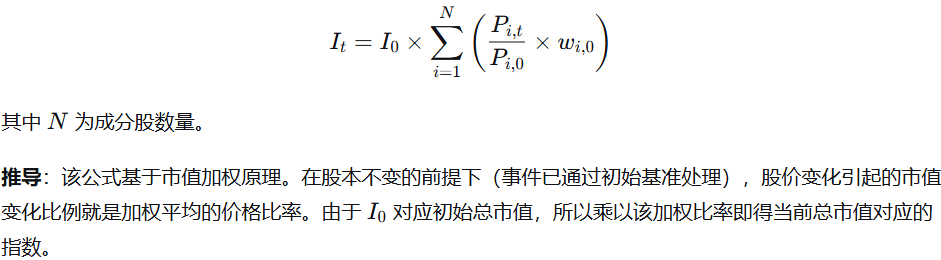

In [10]:
# 计算实时指数和实时基差
def get_realtime_computing_index(index_code,I_base,P_base_dict,weight_dict,CFE_list): 
    # 函数参数要注意这个指数和后面的前一天收盘价还有成分股收盘价字典以及权重字典要日期、内容对应。CFE_list是指期货合约代码列表，用来算实时基差
    # 获取实时股票数据和实时指数市价
    real_time_index_data = xtdata.get_full_tick([index_code])
    real_time_index = real_time_index_data[index_code]['lastPrice']
    ret_weight_data = xtdata.get_index_weight(index_code)
    code_list = list(ret_weight_data.keys())
    # 获取code_list中的所有股票的实时tick数据，每三秒更新一次
    code_data = xtdata.get_full_tick(code_list)
    # 获取CFE_list中的所有期货的实时数据
    CFE_data = xtdata.get_full_tick(CFE_list)
    # 用实时股票市价计算实时指数，用实时期货价格计算实时基差
    S_t = 0
    for code in code_list:
        P_t = code_data[code]['lastPrice']
        P_base = P_base_dict[code]
        W_base = weight_dict[code]
        S_t += W_base * (P_t / P_base)
    I_t = I_base * (S_t / 100)
    print(f'实时推送指数为{real_time_index},计算指数I_t为{I_t},误差为{real_time_index - I_t}，误差率为{(real_time_index - I_t) / real_time_index}')
    for CFE in CFE_list:
        print(f"{CFE}的当前价格为{CFE_data[CFE]['lastPrice']}，推送基差为{real_time_index-CFE_data[CFE]['lastPrice']},计算基差为{I_t-CFE_data[CFE]['lastPrice']}")
# CFE_list = ['IM2604.IF','IM2605.IF','IM2606.IF']
CFE_list = ['IM2604.IF']

get_realtime_computing_index(index_code,I_base,P_base_dict,weight_dict,CFE_list)


实时推送指数为7751.181,计算指数I_t为7751.19000017617,误差为-0.00900017617004778，误差率为-1.1611361120386403e-06
IM2604.IF的当前价格为7650，推送基差为101.18099999999959,计算基差为101.19000017616963


In [6]:
# import time
# while True:
#     print(datetime.datetime.now())
#     get_realtime_computing_index(index_code,I_base,P_base_dict,weight_dict,CFE_list)
#     time.sleep(3)

### 以下都是草稿

In [7]:
# import datetime
# # stock_code = 'IM2603.IF'
# # stock_code = '512100.SH'
# stock_code = '688226.SH'
# # stock_code = ['688226.SH','000009.SZ']
# last_price = None
# def on_data(datas):
#     # get_realtime_computing_index(index_code,I_base,P_base_dict,weight_dict,CFE_list)
#     for stock_code in datas:
#         print(stock_code,datas[stock_code])
#         print(stock_code,datas[stock_code][0]['askVol'],datas[stock_code][0]['bidVol'])        
      
# subscribe_id = xtdata.subscribe_quote(stock_code, period='tick', start_time='', end_time='', count=0, callback=on_data)
# # print(last_price)

In [8]:
# 取消订阅
# xtdata.unsubscribe_quote(subscribe_id)

In [9]:
# # 初始模拟股票交易账户
# class TradingAccount:
#     def __init__(self, account_id, initial_balance):
#         """
#         初始化交易账户
#         :param account_id: 账号(str)
#         :param initial_balance: 初始资金(float)
#         """
#         self.account_id = account_id
#         self.initial_balance = initial_balance
#         self.outside_balance = initial_balance  # 仓外余额
#         self.inside_market_value = 0.0  # 仓内市值
#         self.total_asset = initial_balance  # 总资产
#         self.holdings = {}  # 持仓，键为商品代码，值为字典
    
#     def get_current_price(self, symbol):
#         # 获取商品当前市价
#         if isinstance(symbol, str):
#             real_time_stock_data = xtdata.get_full_tick([symbol])
#             real_time_stock_lastPrice  = float('{:.3f}'.format(real_time_stock_data[symbol]['lastPrice']))
            
#             return real_time_stock_lastPrice
#         if isinstance(symbol, list):
#             real_time_stock_data = xtdata.get_full_tick(symbol)
#             real_time_stock_lastPrice = {stock: real_time_stock_data[stock]['lastPrice'] for stock in symbol}
#             return real_time_stock_lastPrice
#     def get_instrument_type(self, symbol):
#         # 获取商品类型
#         key_list= " ".join(xtdata.get_instrument_type(symbol).keys())
#         type = ""
#         if "STOCK" in key_list: # 股票
#             type = "STOCK"
#         elif "FUND" in key_list: # 基金
#             type = "FUND"
#         elif "INDEX" in key_list: # 指数
#             type = "INDEX"
#         else:
#             type = "FUTURES"    # 期货
#         return type
    
#     def buy(self, symbol, quantity):
#         """
#         买入函数
#         :param symbol: 商品代码(str)
#         :param quantity: 买入数量(int)
#         :return: 买入是否成功(bool)
#         """
#         current_price = self.get_current_price(symbol)
        
#         # volume_multiple = xtdata.get_instrument_detail(symbol, iscomplete=False)['VolumeMultiple']

#         total_cost = current_price * quantity
        
#         if self.outside_balance >= total_cost:
#             # 买入成功
#             self.outside_balance -= total_cost
#             self.inside_market_value += total_cost
#             self.total_asset = self.outside_balance + self.inside_market_value
            
#             # 更新持仓信息
#             current_time = datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')
            
#             if symbol in self.holdings:
#                 # 已有持仓，更新信息
#                 holding = self.holdings[symbol]
#                 old_quantity = holding['quantity']
#                 old_buy_amount = holding['buy_amount']
                
#                 new_quantity = old_quantity + quantity
#                 new_buy_amount = old_buy_amount + total_cost
#                 new_buy_price = new_buy_amount / new_quantity
                
#                 holding.update({
#                     'last_trade_time': current_time,
#                     'buy_price': new_buy_price,
#                     'quantity': new_quantity,
#                     'buy_amount': new_buy_amount,
#                     'current_price': current_price,
#                     'current_market_value': new_quantity * current_price,
#                     'profit_loss_ratio': (new_quantity * current_price - new_buy_amount) / new_buy_amount
#                 })
#             else:
#                 # 新持仓
#                 self.holdings[symbol] = {
#                     'last_trade_time': current_time,
#                     'type': self.get_instrument_type(symbol),
#                     'buy_price': current_price,
#                     'quantity': quantity,
#                     'buy_amount': total_cost,
#                     'current_price': current_price,
#                     'current_market_value': total_cost,
#                     'profit_loss_ratio': 0.0
#                 }
            
#             print(f"以{total_cost:.2f}成交{quantity}股{symbol}")
#             return True
#         else:
#             # 买入失败，余额不足
#             print("买入失败，仓外余额不足")
#             return False
    
#     def sell(self, symbol, quantity):
#         """
#         卖出函数
#         :param symbol: 商品代码(str)
#         :param quantity: 卖出数量(int)
#         :return: 卖出是否成功(bool)
#         """
#         if symbol not in self.holdings:
#             print("卖出失败，持仓中没有该商品")
#             return False
        
#         holding = self.holdings[symbol]
#         if quantity > holding['quantity']:
#             print("卖出失败，卖出数量大于持仓量")
#             return False
        
#         # 卖出成功
#         current_price = self.get_current_price(symbol)
#         total_proceeds = current_price * quantity
        
#         # 更新账户信息
#         self.inside_market_value -= total_proceeds
#         self.outside_balance += total_proceeds
#         self.total_asset = self.outside_balance + self.inside_market_value
        
#         # 更新持仓信息
#         current_time = datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        
#         remaining_quantity = holding['quantity'] - quantity
#         if remaining_quantity > 0:
#             # 还有剩余持仓
#             holding.update({
#                 'last_trade_time': current_time,
#                 'quantity': remaining_quantity,
#                 'current_price': current_price,
#                 'current_market_value': remaining_quantity * current_price,
#                 'profit_loss_ratio': (remaining_quantity * current_price + total_proceeds - holding['buy_amount']) / holding['buy_amount']
#             })
#         else:
#             # 全部卖出，移除持仓
#             del self.holdings[symbol]
        
#         print(f"以{total_proceeds:.2f}成交{quantity}股{symbol}")
#         return True
    
#     def __str__(self):
#         """
#         打印账户信息
#         :return: 账户信息字符串
#         """
#         info = f"账号: {self.account_id}\n"
#         info += f"仓外余额: {self.outside_balance:.2f}\n"        
#         current_holdings_lastPrice = self.get_current_price(list(self.holdings.keys()))

#         for stock in self.holdings:
#             self.holdings[stock]['current_price'] = current_holdings_lastPrice[stock]
#             self.holdings[stock]['current_market_value'] = self.holdings[stock]['current_price'] * self.holdings[stock]['quantity']
#             self.holdings[stock]['profit_loss_ratio'] = (self.holdings[stock]['current_market_value'] - self.holdings[stock]['buy_amount']) / self.holdings[stock]['buy_amount']
#         self.inside_market_value = sum(self.holdings[stock]['current_market_value'] for stock in self.holdings)
#         self.total_asset = self.inside_market_value + self.outside_balance
#         info += f"仓内市值: {self.inside_market_value:.3f}\n"
#         info += f"总资产: {self.total_asset:.3f}\n"

#         info += "持仓:\n"
#         if not self.holdings:
#             info += "  无持仓\n"
#         else:
#             for symbol, holding in self.holdings.items():
#                 info += f"  {holding['type']} {symbol}:\n"
#                 info += f"    最近交易时间: {holding['last_trade_time']}\n"
#                 info += f"    买入时市价: {holding['buy_price']:.3f}\n"
#                 info += f"    持仓量: {holding['quantity']}\n"
#                 info += f"    买入金额: {holding['buy_amount']:.2f}\n"
#                 info += f"    当前市价: {holding['current_price']:.3f}\n"
#                 info += f"    当前仓位市值: {holding['current_market_value']:.3f}\n"
#                 info += f"    当前盈亏比: {holding['profit_loss_ratio']:.4f}\n"
#         return info
    
#     def auto_trade_stock(self, stock_code, buy_price, stop_loss_price, take_profit_price, quantity, max_trades):
#         """
#         自动监控交易函数
#         :param stock_code: 商品代码(str)
#         :param buy_price: 监控买入价(float)
#         :param stop_loss_price: 止损卖出价(float)
#         :param take_profit_price: 止盈卖出价(float)
#         :param quantity: 买入量(int)
#         :param max_trades: 交易次数(int)
#         :return: 订阅ID
#         """
#         # 初始化交易状态
#         self._trade_status = {
#             'stock_code': stock_code,
#             'buy_price': buy_price,
#             'stop_loss_price': stop_loss_price,
#             'take_profit_price': take_profit_price,
#             'quantity': quantity,
#             'max_trades': max_trades,
#             'trade_count': 0,
#             'subscribe_id': None,
#             'is_holding': False
#         }
#         # 定义回调函数
#         def on_data(datas):
#             if stock_code not in datas:
#                 return
#             # 获取实时数据
#             data = datas[stock_code][0]
#             last_price = data['lastPrice']
#             ask_prices = data['askPrice']  # 委卖价
#             bid_prices = data['bidPrice']  # 委买价
#             ask_vols = data['askVol']      # 委卖量
#             bid_vols = data['bidVol']      # 委买量
            
#             # 打印实时行情
#             current_time = datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')
#             print(f"{current_time}")
#             print(f"股票代码为{stock_code}, 目前市价为{last_price}")
            
#             # 检查交易次数
#             if self._trade_status['trade_count'] >= max_trades:
#                 print(f"已达到最大交易次数{max_trades}，停止自动交易")
#                 self.stop_auto_trade_stock()
#                 return
            
#             # 检查买入条件
#             if not self._trade_status['is_holding']:
#                 if (last_price <= buy_price and last_price > stop_loss_price):
#                     # 执行买入
#                     success = self.buy(stock_code, quantity)
#                     if success:
#                         self._trade_status['is_holding'] = True
#                         print(f"自动交易第{self._trade_status['trade_count'] + 1}次: 买入成功")
#                     else:
#                         print(f"仓外余额不做，买入失败")
#                         self.stop_auto_trade()
#                         return
#             # 检查卖出条件
#             else:                        
#                 if (last_price <= stop_loss_price or last_price >= take_profit_price):
#                     # 执行卖出
#                     success = self.sell(stock_code, quantity)
#                     if success:
#                         self._trade_status['is_holding'] = False
#                         print(f"自动交易第{self._trade_status['trade_count'] + 1}次: 卖出成功")
#                         self._trade_status['trade_count'] += 1
#         # 订阅行情
#         subscribe_id = xtdata.subscribe_quote(stock_code, period='tick', callback=on_data)
#         self._trade_status['subscribe_id'] = subscribe_id
#         print(f"开始自动交易监控，订阅ID: {subscribe_id}")
#         print(f"监控股票: {stock_code}")
#         print(f"买入价格: {buy_price}, 止损价格: {stop_loss_price}, 止盈价格: {take_profit_price}")
#         print(f"买入量: {quantity}, 最大交易次数: {max_trades}")
        
#         return subscribe_id
    
#     def stop_auto_trade_stock(self):
#         """
#         停止自动交易
#         """
#         if hasattr(self, '_trade_status') and self._trade_status['subscribe_id']:
#             subscribe_id = self._trade_status['subscribe_id']
#             xtdata.unsubscribe_quote(subscribe_id)
#             print(f"已取消订阅，订阅ID: {subscribe_id}")
#             self._trade_status['subscribe_id'] = None
#         else:
#             print("没有正在进行的自动交易")